# Seoul MMH site selection: Using DRL-LP framework
# 1. model evaluation after retraining with Seoul dataset

- dataset comfiguration

    - demand points: Seoul's 500m population grid
    
    - candidate facilities: 100 randomly selected medical facilities in Seoul

    - number of facilities selected: 20
    
    - facility service radius: approximately 2000m

## 1-1. install required packages

In [ ]:
from utils import torch_load_cpu, load_problem, get_inner_model, move_to
from nets.attention_model import AttentionModel
from tensorboard_logger import Logger as TbLogger
import torch
from torch.utils.data import DataLoader
import numpy as np
from Algorithm.GA import GeneticAlgorithm
import random
from matplotlib import pyplot as plt
import geopandas as gpd
import pandas as pd
from gurobipy import *
import time
from tqdm import tqdm
import copy
import pickle
from eval import _eval_dataset
from utils.data_utils import save_dataset
from utils import load_model
from datetime import timedelta
import os
import csv
import json

from collections import Counter


In [62]:
from joblib import Parallel, delayed

## 1-2. model problem setting: ReCovNet(Zhong et al., 2024)

- Refer to the literature below for the ReCovNet implementation code
    Zhong, Y., Wang, S., Liang, H., Wang, Z., Zhang, X., Chen, X., & Su, C. (2024). ReCovNet: Reinforcement learning with covering information for solving maximal coverage billboards location problem. International Journal of Applied Earth Observation and Geoinformation, 128, 103710.
    https://doi.org/10.1016/j.jag.2024.103710

In [3]:
# load the run args
%run options

# change some run args
opts.n_users = 2152
opts.p = 20
opts.r = 0.05


# Set the random seed
torch.manual_seed(2023)
np.random.seed(2023)
random.seed(2023)
torch.cuda.manual_seed(2023)
torch.cuda.manual_seed_all(2023)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Optionally configure tensorboard
tb_logger = None
if not opts.no_tensorboard:
    tb_logger = TbLogger(os.path.join(opts.log_dir, "{}_{}".format(opts.problem, opts.n_users, opts.n_facilities), opts.run_name))

# Set the device
use_cuda=True
opts.device = torch.device("cuda" if use_cuda else "cpu")
problem = load_problem(opts.problem)

In [4]:
print(opts)

Namespace(baseline=None, batch_size=640, bl_alpha=0.05, bl_warmup_epochs=0, checkpoint_encoder=False, checkpoint_epochs=1, data_distribution=None, device=device(type='cuda'), embedding_dim=128, epoch_size=128000, epoch_start=0, eval_batch_size=1000, eval_only=False, exp_beta=0.8, hidden_dim=128, load_path=None, log_dir='logs', log_step=50, lr_critic=0.0001, lr_decay=1, lr_model=0.0001, max_grad_norm=1.0, model='attention', n_encode_layers=3, n_epochs=500, n_facilities=100, n_users=2152, no_cuda=False, no_progress_bar=False, no_tensorboard=False, normalization='batch', output_dir='outputs', p=20, problem='MCLP', r=0.05, resume=None, run_name='100_20_20260311T203006', save_dir='outputs\\MCLP\\100_20_20260311T203006', seed=2023, shrink_size=None, tanh_clipping=10.0, use_cuda=True, val_dataset=None, val_size=2000)


In [5]:
model_class = {
    # 'pointer': PointerNetwork,
    'attention': AttentionModel
}.get(opts.model, None)

assert model_class is not None, "Unknown model: {}".format(model_class)
model = model_class(
    opts.embedding_dim,
    opts.hidden_dim,
    problem,
    n_encode_layers=opts.n_encode_layers,
    mask_inner=True,
    mask_logits=True,
    normalization=opts.normalization,
    tanh_clipping=opts.tanh_clipping,
    checkpoint_encoder=opts.checkpoint_encoder,
    shrink_size=opts.shrink_size,
    dy=False
).to(opts.device)

model

AttentionModel(
  (init_embed): Linear(in_features=2, out_features=128, bias=True)
  (init_dynamic): Linear(in_features=1, out_features=32, bias=True)
  (l2_dynamic): Linear(in_features=32, out_features=64, bias=True)
  (l3_dynamic): Linear(in_features=64, out_features=128, bias=True)
  (embedder): GraphAttentionEncoder(
    (layers): Sequential(
      (0): MultiHeadAttentionLayer(
        (0): SkipConnection(
          (module): MultiHeadAttention()
        )
        (1): Normalization(
          (normalizer): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (2): SkipConnection(
          (module): Sequential(
            (0): Linear(in_features=128, out_features=512, bias=True)
            (1): ReLU()
            (2): Linear(in_features=512, out_features=128, bias=True)
          )
        )
        (3): Normalization(
          (normalizer): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
  

## 1-3. model performance after traing using test datasets

### trained models list
- **model A** : epoch (499, final) & sampling size (128)

- **model B** : epoch (499, final) & sampline size (1280)

- **model C** : epoch (483, best) & sampling size (128)

- **model D** : epoch (483, best) & sampline size (1280)

### model A

In [6]:
opts.load_path = './outputs/MCLP/100_20_20260223T212334/epoch-499.pt'

# load model from load_path
assert opts.load_path is None or opts.resume is None, "Only one of load path and resume can be given"
load_path = opts.load_path if opts.load_path is not None else opts.resume
if load_path is not None:
    print('  [*] Loading the trained model from {}'.format(load_path))
    load_data = torch_load_cpu(load_path)

# Overwrite model parameters by parameters to load q
model_ = get_inner_model(model)
model.load_state_dict({**model_.state_dict(), **load_data.get('model', {})})

  [*] Loading the trained model from ./outputs/MCLP/100_20_20260223T212334/epoch-499.pt


<All keys matched successfully>

In [6]:
def get_best(sequences, cost, ids=None, batch_size=None):
    """
    Ids contains [0, 0, 0, 1, 1, 2, ..., n, n, n] if 3 solutions found for 0th instance, 2 for 1st, etc
    :param sequences:
    :param lengths:
    :param ids:
    :return: list with n sequences and list with n lengths of solutions
    """
    if ids is None:
        idx = cost.argmin()
        return sequences[idx:idx+1, ...], cost[idx:idx+1, ...]

    splits = np.hstack([0, np.where(ids[:-1] != ids[1:])[0] + 1])
    mincosts = np.minimum.reduceat(cost, splits)

    group_lengths = np.diff(np.hstack([splits, len(ids)]))
    all_argmin = np.flatnonzero(np.repeat(mincosts, group_lengths) == cost)
    result = np.full(len(group_lengths) if batch_size is None else batch_size, -1, dtype=int)

    result[ids[all_argmin[::-1]]] = all_argmin[::-1]

    return [sequences[i] if i >= 0 else None for i in result], [cost[i] if i >= 0 else math.inf for i in result]

In [8]:
opts.o = None
opts.val_size = 10
opts.eval_batch_size = 1
opts.max_calc_batch_size = 1280000
opts.results_dir = 'results'
opts.softmax_temperature = 1.0
opts.decode_strategy = 'sample'
opts.offset = 0
opts.f = True
width = 128

In [7]:
def eval_dataset(dataset_path, width, softmax_temp, opts):
    use_cuda = torch.cuda.is_available() and not opts.no_cuda
    
    device = torch.device("cuda:0" if use_cuda else "cpu")
    print("Device: {}".format(device))

    dataset = model.problem.make_dataset(filename=dataset_path)
    results = _eval_dataset(model, dataset, width, softmax_temp, opts, device)

    # This is parallelism, even if we use multiprocessing (we report as if we did not use multiprocessing, e.g. 1 GPU)
    parallelism = opts.eval_batch_size

    costs, tours, durations = zip(*results)  # Not really costs since they should be negative

    print("Average cost: {} +- {}".format(np.mean(costs), 2 * np.std(costs) / np.sqrt(len(costs))))
    print("Average serial duration: {} +- {}".format(
        np.mean(durations), 2 * np.std(durations) / np.sqrt(len(durations))))
    print("Average parallel duration: {}".format(np.mean(durations) / parallelism))
    print("Calculated total duration: {}".format(timedelta(seconds=int(np.sum(durations) / parallelism))))

    dataset_basename, ext = os.path.splitext(os.path.split(dataset_path)[-1])
    model_name = "_".join(os.path.normpath(os.path.splitext(opts.model)[0]).split(os.sep)[-2:])
    if opts.o is None:
        results_dir = os.path.join(opts.results_dir, model.problem.NAME, dataset_basename)
        os.makedirs(results_dir, exist_ok=True)

        out_file = os.path.join(results_dir, "{}-{}-{}{}-t{}-{}-{}{}".format(
            dataset_basename, model_name,
            opts.decode_strategy,
            width if opts.decode_strategy != 'greedy' else '',
            softmax_temp, opts.offset, opts.offset + len(costs), ext
        ))
    else:
        out_file = opts.o

    assert opts.f or not os.path.isfile(
        out_file), "File already exists! Try running with -f option to overwrite."

    save_dataset((results, parallelism), out_file)

    return costs, tours, durations

In [10]:
dataset_path = './data/2603_data/test_20_2000.pkl'

In [11]:
eval_dataset(dataset_path, width, opts.softmax_temperature, opts)

Device: cuda:0


100%|██████████| 2000/2000 [01:22<00:00, 24.30it/s]


Average cost: -4417.93115234375 +- 4.3088108012408
Average serial duration: 0.040697500586509706 +- 0.0021270538421214492
Average parallel duration: 0.040697500586509706
Calculated total duration: 0:01:21


((-4312.952,
  -4506.213,
  -4405.5723,
  -4473.5303,
  -4521.0547,
  -4332.8486,
  -4391.8687,
  -4394.7666,
  -4389.8154,
  -4406.6855,
  -4430.535,
  -4473.1016,
  -4329.6,
  -4383.796,
  -4420.261,
  -4549.2715,
  -4464.502,
  -4397.3613,
  -4439.9053,
  -4453.6045,
  -4396.2812,
  -4462.2207,
  -4319.2773,
  -4360.633,
  -4394.009,
  -4421.365,
  -4440.4985,
  -4306.8975,
  -4421.6655,
  -4451.528,
  -4365.071,
  -4404.544,
  -4448.585,
  -4459.0107,
  -4306.8076,
  -4592.6533,
  -4358.83,
  -4416.533,
  -4527.25,
  -4230.9404,
  -4412.5005,
  -4571.7495,
  -4564.6216,
  -4505.295,
  -4490.5527,
  -4500.9644,
  -4501.6885,
  -4324.175,
  -4226.956,
  -4355.0693,
  -4304.8555,
  -4386.512,
  -4459.384,
  -4537.1924,
  -4209.413,
  -4429.924,
  -4448.374,
  -4452.3545,
  -4566.586,
  -4403.2773,
  -4354.8164,
  -4350.795,
  -4574.254,
  -4305.671,
  -4484.135,
  -4305.542,
  -4470.6475,
  -4574.243,
  -4380.547,
  -4369.297,
  -4328.381,
  -4422.158,
  -4479.38,
  -4351.5586,
  -447

In [12]:
with open("./results/MCLP/test_20_2000/test_20_2000-attention-sample128-t1.0-0-2000.pkl", "rb") as f:
    result_file = pickle.load(f)

In [13]:
cost_col = []
avg_cost_per_facility = []
for i in range(len(result_file[0])):
    cost_col.append(-1*result_file[0][i][0])
    avg_cost_per_facility.append(-1*result_file[0][i][0]/(len(result_file[0][i][1])))
    
min_cost = min(cost_col)
max_cost = max(cost_col)
mean_cost = sum(cost_col)/len(cost_col)
std_cost = np.std(cost_col)

print('Min Cost:', min_cost)
print('Max Cost:', max_cost)
print('Mean Cost:', mean_cost) 
print('Std Cost:', std_cost)
print('Length of Cost:', len(cost_col))
    
print('Average Cost per Facility:', sum(avg_cost_per_facility)/len(avg_cost_per_facility))

Min Cost: 4083.624755859375
Max Cost: 4732.10595703125
Mean Cost: 4417.9309327392575
Std Cost: 96.34794282797245
Length of Cost: 2000
Average Cost per Facility: 220.89654663696348


### model B

In [14]:
width = 1280

In [15]:
eval_dataset(dataset_path, width, opts.softmax_temperature, opts)

Device: cuda:0


100%|██████████| 2000/2000 [02:47<00:00, 11.94it/s]


Average cost: -4423.4912109375 +- 4.2682919638586005
Average serial duration: 0.08313487911224365 +- 0.0004024164784977305
Average parallel duration: 0.08313487911224365
Calculated total duration: 0:02:46


((-4314.58,
  -4511.964,
  -4406.1294,
  -4473.5303,
  -4546.4375,
  -4332.8486,
  -4394.69,
  -4394.7666,
  -4399.691,
  -4428.945,
  -4443.9033,
  -4473.1016,
  -4329.9375,
  -4383.796,
  -4426.4785,
  -4549.2715,
  -4483.7,
  -4402.469,
  -4443.8467,
  -4453.6045,
  -4396.2812,
  -4465.2686,
  -4355.7817,
  -4377.172,
  -4397.787,
  -4435.306,
  -4456.133,
  -4311.575,
  -4434.6436,
  -4465.056,
  -4373.433,
  -4430.1294,
  -4466.1455,
  -4459.0107,
  -4305.81,
  -4592.6533,
  -4363.1987,
  -4416.533,
  -4527.25,
  -4244.83,
  -4424.9365,
  -4571.7495,
  -4579.5264,
  -4520.238,
  -4490.5527,
  -4500.9644,
  -4501.6885,
  -4350.838,
  -4228.9287,
  -4366.424,
  -4304.8555,
  -4386.512,
  -4455.574,
  -4540.3247,
  -4209.413,
  -4456.7314,
  -4449.428,
  -4459.4775,
  -4568.4307,
  -4412.8413,
  -4354.8164,
  -4350.795,
  -4574.254,
  -4320.276,
  -4494.8335,
  -4305.542,
  -4475.1377,
  -4574.243,
  -4386.335,
  -4373.667,
  -4328.9106,
  -4439.29,
  -4501.075,
  -4359.8047,
  -4473

In [16]:
with open("./results/MCLP/test_20_2000/test_20_2000-attention-sample1280-t1.0-0-2000.pkl", "rb") as f:
    result_file = pickle.load(f)

In [18]:
cost_col = []
avg_cost_per_facility = []
for i in range(len(result_file[0])):
    cost_col.append(-1*result_file[0][i][0])
    avg_cost_per_facility.append(-1*result_file[0][i][0]/(len(result_file[0][i][1])))
    
min_cost = min(cost_col)
max_cost = max(cost_col)
mean_cost = sum(cost_col)/len(cost_col)
std_cost = np.std(cost_col)

print('Min Cost:', min_cost)
print('Max Cost:', max_cost)
print('Mean Cost:', mean_cost) 
print('Std Cost:', std_cost)
print('Length of Cost:', len(cost_col))
    
print('Average Cost per Facility:', sum(avg_cost_per_facility)/len(avg_cost_per_facility))

Min Cost: 4084.5458984375
Max Cost: 4732.10595703125
Mean Cost: 4423.491325805664
Std Cost: 95.44190610240365
Length of Cost: 2000
Average Cost per Facility: 221.17456629028362


### model C

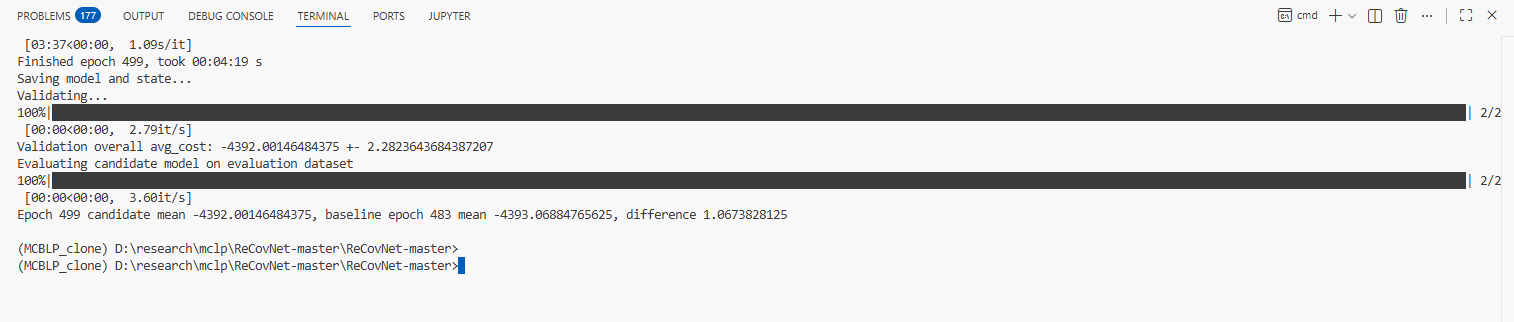

In [19]:
opts.load_path = './outputs/MCLP/100_20_20260223T212334/epoch-483.pt'
# load model from load_path
assert opts.load_path is None or opts.resume is None, "Only one of load path and resume can be given"
load_path = opts.load_path if opts.load_path is not None else opts.resume
if load_path is not None:
    print('  [*] Loading the trained model from {}'.format(load_path))
    load_data = torch_load_cpu(load_path)

# Overwrite model parameters by parameters to load q
model_ = get_inner_model(model)
model.load_state_dict({**model_.state_dict(), **load_data.get('model', {})})

  [*] Loading the trained model from ./outputs/MCLP/100_20_20260223T212334/epoch-483.pt


<All keys matched successfully>

In [20]:
width = 128
eval_dataset(dataset_path, width, opts.softmax_temperature, opts)

Device: cuda:0


100%|██████████| 2000/2000 [01:27<00:00, 22.92it/s]


Average cost: -4418.6015625 +- 4.279234489509601
Average serial duration: 0.04319274866580963 +- 0.0004525650954780249
Average parallel duration: 0.04319274866580963
Calculated total duration: 0:01:26


((-4297.5625,
  -4511.964,
  -4405.5723,
  -4473.5303,
  -4536.4023,
  -4363.173,
  -4375.676,
  -4336.2544,
  -4414.1533,
  -4410.5283,
  -4453.1816,
  -4479.159,
  -4307.5557,
  -4366.9326,
  -4419.001,
  -4537.874,
  -4483.7,
  -4402.881,
  -4438.7114,
  -4453.6045,
  -4396.2812,
  -4449.3794,
  -4297.759,
  -4391.1875,
  -4402.799,
  -4421.365,
  -4456.133,
  -4313.384,
  -4444.589,
  -4464.7026,
  -4370.9814,
  -4420.778,
  -4466.5137,
  -4463.675,
  -4307.7676,
  -4622.7734,
  -4357.7163,
  -4407.441,
  -4523.054,
  -4231.3906,
  -4384.213,
  -4570.085,
  -4587.422,
  -4512.092,
  -4490.5527,
  -4498.8057,
  -4501.6885,
  -4346.6587,
  -4219.6035,
  -4322.505,
  -4267.3735,
  -4386.512,
  -4459.384,
  -4535.284,
  -4195.9956,
  -4425.7666,
  -4459.395,
  -4452.838,
  -4568.4307,
  -4412.5127,
  -4368.0835,
  -4351.1865,
  -4554.6284,
  -4292.162,
  -4493.3125,
  -4302.422,
  -4475.6396,
  -4574.243,
  -4383.087,
  -4373.667,
  -4328.381,
  -4423.6484,
  -4479.38,
  -4352.711,
  -

In [22]:
with open("./results/MCLP/test_20_2000/test_20_2000-attention-sample128-t1.0-0-2000.pkl", "rb") as f:
    result_file = pickle.load(f)
    
cost_col = []
avg_cost_per_facility = []
for i in range(len(result_file[0])):
    cost_col.append(-1*result_file[0][i][0])
    avg_cost_per_facility.append(-1*result_file[0][i][0]/(len(result_file[0][i][1])))
    
min_cost = min(cost_col)
max_cost = max(cost_col)
mean_cost = sum(cost_col)/len(cost_col)
std_cost = np.std(cost_col)

print('Min Cost:', min_cost)
print('Max Cost:', max_cost)
print('Mean Cost:', mean_cost) 
print('Std Cost:', std_cost)
print('Length of Cost:', len(cost_col))
    
print('Average Cost per Facility:', sum(avg_cost_per_facility)/len(avg_cost_per_facility))

Min Cost: 4056.087890625
Max Cost: 4732.10595703125
Mean Cost: 4418.601719116211
Std Cost: 95.68659538482567
Length of Cost: 2000
Average Cost per Facility: 220.93008595581048


### model D

In [23]:
width = 1280
eval_dataset(dataset_path, width, opts.softmax_temperature, opts)

Device: cuda:0


100%|██████████| 2000/2000 [02:43<00:00, 12.22it/s]


Average cost: -4424.662109375 +- 4.242386248334362
Average serial duration: 0.08120004880428314 +- 0.0002528370250138432
Average parallel duration: 0.08120004880428314
Calculated total duration: 0:02:42


((-4310.381,
  -4511.964,
  -4409.62,
  -4473.5303,
  -4536.4023,
  -4363.173,
  -4391.8687,
  -4361.785,
  -4414.1533,
  -4454.84,
  -4453.1816,
  -4483.0063,
  -4311.259,
  -4383.796,
  -4419.001,
  -4537.874,
  -4483.7,
  -4417.294,
  -4448.664,
  -4472.1914,
  -4397.5957,
  -4454.8457,
  -4319.2095,
  -4391.1875,
  -4402.799,
  -4435.6123,
  -4460.7314,
  -4313.384,
  -4444.9844,
  -4468.636,
  -4371.896,
  -4426.1475,
  -4470.2246,
  -4463.675,
  -4310.8203,
  -4622.7734,
  -4371.0605,
  -4416.2573,
  -4523.054,
  -4248.163,
  -4434.0146,
  -4571.7495,
  -4587.422,
  -4524.9033,
  -4490.5527,
  -4503.915,
  -4501.6885,
  -4351.203,
  -4228.9287,
  -4359.372,
  -4267.3735,
  -4386.512,
  -4459.384,
  -4540.3247,
  -4195.9956,
  -4444.2476,
  -4459.395,
  -4452.838,
  -4575.4062,
  -4419.1816,
  -4372.1924,
  -4367.34,
  -4574.254,
  -4316.77,
  -4492.8564,
  -4302.422,
  -4486.48,
  -4574.243,
  -4383.087,
  -4377.8115,
  -4328.381,
  -4431.166,
  -4482.837,
  -4360.3345,
  -4479.9

In [24]:
with open("./results/MCLP/test_20_2000/test_20_2000-attention-sample1280-t1.0-0-2000.pkl", "rb") as f:
    result_file = pickle.load(f)
    
cost_col = []
avg_cost_per_facility = []
for i in range(len(result_file[0])):
    cost_col.append(-1*result_file[0][i][0])
    avg_cost_per_facility.append(-1*result_file[0][i][0]/(len(result_file[0][i][1])))
    
min_cost = min(cost_col)
max_cost = max(cost_col)
mean_cost = sum(cost_col)/len(cost_col)
std_cost = np.std(cost_col)

print('Min Cost:', min_cost)
print('Max Cost:', max_cost)
print('Mean Cost:', mean_cost) 
print('Std Cost:', std_cost)
print('Length of Cost:', len(cost_col))
    
print('Average Cost per Facility:', sum(avg_cost_per_facility)/len(avg_cost_per_facility))

Min Cost: 4079.8525390625
Max Cost: 4732.10595703125
Mean Cost: 4424.662331298829
Std Cost: 94.86263718175015
Length of Cost: 2000
Average Cost per Facility: 221.2331165649414


## 1-4. comparision with LP & Heuristic using test dataset

### LP

In [8]:
def gurobi_solver_MCLP(users, facilities, demand, PN, A):
    # Problem datas
    N = len(users)
    M = len(facilities)

    model = Model('MCLP')
    model.setParam('OutputFlag', False)
    model.setParam('MIPFocus', 2)
    # Add variables
    client_var = {}
    serv_var = {}

    # Add Client Decision Variables and Service Decision Variables
    for j in range(N):
        client_var[j] = model.addVar(vtype="B", name="y(%s)"%j)
    for i in range(M):
        serv_var[i] = model.addVar(vtype="B", name="x(%s)"%i)
    # Update Model Variables
    model.update()
    #     Set Objective Function
    model.setObjective(quicksum(demand[j]*client_var[j] for j in range(N)), GRB.MAXIMIZE)
    #     Add Constraints
    # Add Coverage Constraints
    for j in range(N):
        model.addConstr(quicksum (A[i,j]*serv_var[i] for i in range(M)) - client_var[j] >= 0,
                        'Coverage_Constraint_%d' % j)

    # Add Facility Constraint
    model.addConstr(quicksum(serv_var[i] for i in range(M)) == PN,
                "Facility_Constraint")

    model.optimize()

    # return a stardard result list
    x_result = []
    for i in range(M):
        x_result.append(serv_var[i].X)
    y_result = []
    for j in range(N):
        y_result.append(client_var[j].X)
    obj = model.ObjVal
    return x_result, y_result, obj

In [9]:
def process_sample(sample):
    users = sample['users'].numpy().astype(float)
    facilities = sample['facilities'].numpy().astype(float)
    demand = sample['demand'].squeeze().numpy().astype(float)
    p = sample['p']
    radius = sample['r']
    
    A = np.sum((facilities[:, np.newaxis, :] - users[np.newaxis, :, :]) ** 2, axis=-1) ** 0.5
    mask1 = A <= radius
    A[mask1] = 1
    A[~mask1] = 0
    
    x_result, _, obj = gurobi_solver_MCLP(users, facilities, demand, p, A)
    solution = [i for i in range(len(x_result)) if x_result[i] == 1.0]
    
    return (obj, solution)

In [27]:
with open("./data/2603_data/test_20_2000.pkl", "rb") as f:
    test_data = pickle.load(f)

In [ ]:
results = Parallel(n_jobs=16, prefer='threads')(delayed(process_sample)(sample) for sample in tqdm(test_data))

with open("./results/MCLP/gurobi_20_2000/gurobi_test_result.pkl", "wb") as f:
    pickle.dump(results, f)

with open("./results/MCLP/gurobi_20_2000/gurobi_test_result.pkl", "rb") as f:
    result_file = pickle.load(f)

  0%|          | 0/2000 [00:00<?, ?it/s]

Set parameter Username
Set parameter Username
Set parameter Username
Set parameter Username
Set parameter LicenseID to value 2646023
Set parameter Username
Set parameter Username
Set parameter Username
Set parameter Username
Set parameter Username
Set parameter LicenseID to value 2646023
Set parameter Username
Set parameter Username
Set parameter Username
Set parameter LicenseID to value 2646023
Set parameter Username
Set parameter LicenseID to value 2646023
Set parameter Username
Set parameter Username
Set parameter Username
Set parameter LicenseID to value 2646023
Set parameter LicenseID to value 2646023
Set parameter LicenseID to value 2646023
Set parameter LicenseID to value 2646023
Academic license - for non-commercial use only - expires 2026-04-01
Set parameter LicenseID to value 2646023
Set parameter LicenseID to value 2646023
Set parameter LicenseID to value 2646023
Set parameter LicenseID to value 2646023
Academic license - for non-commercial use only - expires 2026-04-01
Set 

  2%|▏         | 32/2000 [00:31<32:28,  1.01it/s]

Freeing default Gurobi environment
Freeing default Gurobi environment


  2%|▏         | 35/2000 [00:34<31:26,  1.04it/s]

...

  2%|▏         | 45/2000 [00:41<22:28,  1.45it/s]

Freeing default Gurobi environment


  2%|▏         | 47/2000 [00:44<37:14,  1.14s/it]

Freeing default Gurobi environment
Freeing default Gurobi environment
Freeing default Gurobi environment
Freeing default Gurobi environment
Freeing default Gurobi environment
Freeing default Gurobi environment
Freeing default Gurobi environment
Freeing default Gurobi environment
Freeing default Gurobi environment
Freeing default Gurobi environment


100%|██████████| 2000/2000 [1:40:20<00:00,  3.01s/it]  


In [32]:
cost_col = []
avg_cost_per_facility = []
for i in range(len(result_file)):
    cost_col.append(result_file[i][0])
    avg_cost_per_facility.append(result_file[i][0]/(len(result_file[i][1])))
    
min_cost = min(cost_col)
max_cost = max(cost_col)
mean_cost = sum(cost_col)/len(cost_col)
std_cost = np.std(cost_col)

print('Min Cost:', min_cost)
print('Max Cost:', max_cost)
print('Mean Cost:', mean_cost) 
print('Std Cost:', std_cost)
print('Length of Cost:', len(cost_col))
    
print('Average Cost per Facility:', sum(avg_cost_per_facility)/len(avg_cost_per_facility))

Min Cost: 4131.178601264954
Max Cost: 4755.811668276787
Mean Cost: 4441.132881835341
Std Cost: 90.23286108389483
Length of Cost: 2000
Average Cost per Facility: 222.05664409176714


### GA

In [33]:
del results

In [10]:
def process_sample2(sample):
    users = sample['users'].numpy().astype(float)
    facilities = sample['facilities'].numpy().astype(float)
    demand = sample['demand'].squeeze().numpy().astype(float)
    p = sample['p']
    radius = sample['r']
    
    A = np.sum((facilities[:, np.newaxis, :] - users[np.newaxis, :, :]) ** 2, axis=-1) ** 0.5
    
    genetic = GeneticAlgorithm(len(users), len(facilities), p, A, radius, demand)
    genetic.optimize()
    obj = np.sum(demand) - genetic.top_chromosome.fitness
    solution = genetic.top_chromosome.content
    
    return (obj, solution)

In [35]:
results = Parallel(n_jobs=16, prefer="threads")(delayed(process_sample2)(sample) for sample in tqdm(test_data))

  0%|          | 0/2000 [00:00<?, ?it/s]

Current top solution: [74, 75, 63, 55, 51, 38, 29, 82, 16, 92, 11, 9, 4, 89, 34, 35, 94, 83, 31, 73] f=4847
Current top solution: [19, 18, 71, 41, 45, 50, 46, 2, 51, 80, 68, 7, 66, 52, 95, 10, 24, 82, 3, 97] f=4790
Current top solution: [69, 82, 14, 24, 30, 10, 22, 75, 86, 97, 19, 28, 59, 45, 46, 49, 89, 48, 1, 98] f=4704
Current top solution: [16, 99, 90, 44, 9, 11, 98, 92, 43, 27, 41, 72, 68, 21, 14, 45, 1, 91, 94, 62] f=4786
Current top solution: [30, 43, 70, 63, 41, 22, 31, 85, 47, 56, 26, 76, 52, 96, 39, 60, 82, 71, 83, 87] f=4965
Current top solution: [19, 20, 40, 50, 65, 99, 29, 93, 77, 73, 55, 84, 12, 91, 11, 68, 46, 92, 1, 7] f=4894
Current top solution: [69, 36, 49, 93, 77, 32, 91, 6, 68, 16, 17, 86, 30, 21, 0, 63, 28, 43, 94, 58] f=4770
Current top solution: [8, 4, 69, 52, 33, 40, 72, 23, 61, 0, 43, 79, 59, 21, 99, 38, 34, 19, 6, 77] f=4987
Current top solution: [71, 43, 96, 68, 17, 4, 53, 23, 6, 5, 67, 12, 61, 24, 80, 64, 83, 65, 59, 49] f=4680
Current top solution: [48, 33

  2%|▏         | 32/2000 [00:14<15:04,  2.18it/s]


Final top solution: [41, 47, 39, 79, 97, 64, 81, 1, 65, 19, 73, 30, 15, 91, 55, 29, 94, 56, 96, 44] f=3852
Time: 00:00:14.6778

Final top solution: [27, 59, 62, 1, 32, 93, 98, 81, 19, 65, 20, 53, 16, 33, 44, 22, 39, 70, 7, 74] f=3887
Time: 00:00:14.6908

Final top solution: [48, 3, 9, 76, 83, 42, 90, 15, 79, 2, 31, 22, 33, 77, 95, 65, 0, 26, 99, 63] f=4023
Time: 00:00:14.7208

Final top solution: [20, 18, 65, 42, 25, 58, 15, 59, 50, 99, 76, 12, 75, 60, 9, 91, 24, 66, 45, 79] f=3997
Time: 00:00:14.7438
Current top solution: [83, 41, 38, 45, 61, 59, 88, 93, 73, 97, 52, 53, 72, 44, 81, 96, 35, 10, 62, 98] f=4852

Final top solution: [47, 72, 8, 42, 66, 62, 24, 28, 64, 32, 41, 52, 50, 90, 43, 4, 89, 29, 68, 46] f=3905
Time: 00:00:14.7648
Current top solution: [92, 88, 95, 55, 6, 68, 39, 32, 96, 98, 34, 58, 97, 10, 94, 41, 79, 1, 25, 61] f=4983

Final top solution: [53, 54, 90, 79, 99, 73, 35, 37, 7, 31, 30, 48, 72, 78, 45, 11, 9, 19, 40, 91] f=3827
Time: 00:00:14.7738

Final top solution:

  2%|▏         | 48/2000 [00:29<20:51,  1.56it/s]

...

 99%|█████████▉| 1984/2000 [38:21<00:27,  1.73s/it]


Final top solution: [54, 72, 0, 73, 96, 93, 13, 61, 9, 33, 98, 69, 92, 97, 75, 30, 46, 39, 47, 94] f=3991
Time: 00:00:28.2640
Current top solution: [85, 49, 16, 23, 38, 99, 51, 63, 9, 61, 76, 41, 54, 12, 82, 48, 3, 93, 33, 32] f=4578

Final top solution: [37, 9, 28, 59, 31, 25, 90, 21, 95, 42, 62, 93, 22, 52, 24, 91, 16, 4, 61, 98] f=3832
Time: 00:00:28.2630
Current top solution: [47, 35, 60, 94, 29, 97, 63, 46, 48, 0, 15, 8, 62, 85, 32, 91, 98, 51, 42, 54] f=4769

Final top solution: [91, 5, 51, 4, 93, 37, 97, 19, 26, 10, 35, 14, 27, 66, 58, 60, 17, 78, 57, 6] f=3941
Time: 00:00:28.1733
Current top solution: [33, 78, 41, 76, 87, 26, 5, 50, 2, 70, 92, 31, 69, 95, 10, 99, 29, 39, 51, 60] f=4799

Final top solution: [78, 58, 66, 27, 94, 17, 49, 67, 59, 95, 6, 54, 53, 19, 4, 0, 21, 76, 3, 97] f=3693
Time: 00:00:28.1077
Current top solution: [12, 51, 89, 25, 98, 18, 42, 79, 83, 3, 64, 35, 88, 10, 15, 4, 97, 38, 44, 28] f=4656

Final top solution: [95, 17, 50, 54, 10, 40, 82, 22, 35, 96, 3

100%|██████████| 2000/2000 [38:49<00:00,  1.16s/it]


Final top solution: [42, 76, 12, 53, 17, 68, 75, 83, 60, 9, 64, 41, 69, 82, 6, 95, 27, 79, 13, 92] f=3821
Time: 00:00:28.4688
Current top solution: [19, 18, 88, 56, 80, 37, 66, 11, 0, 71, 83, 35, 40, 22, 59, 17, 91, 50, 48, 23] f=4557



Final top solution: [41, 18, 49, 53, 97, 47, 72, 99, 19, 48, 68, 74, 33, 43, 62, 15, 65, 27, 20, 21] f=3824
Time: 00:00:28.4253
Current top solution: [54, 14, 50, 74, 95, 32, 47, 5, 51, 87, 96, 53, 33, 68, 45, 10, 77, 89, 72, 76] f=4715

Final top solution: [7, 1, 3, 10, 45, 9, 22, 52, 76, 14, 34, 91, 36, 32, 80, 93, 63, 29, 12, 33] f=4047
Time: 00:00:28.3139
Current top solution: [62, 28, 80, 22, 37, 85, 32, 75, 46, 90, 36, 97, 45, 44, 52, 50, 8, 24, 55, 63] f=4693

Final top solution: [44, 84, 65, 61, 81, 0, 98, 35, 54, 69, 92, 14, 88, 50, 83, 82, 66, 1, 95, 70] f=3824
Time: 00:00:28.7142
Current top solution: [78, 75, 79, 17, 48, 3, 93, 15, 64, 43, 94, 44, 19, 30, 71, 69, 66, 41, 68, 81] f=4694

Final top solution: [15, 52, 83, 95, 42, 63, 4, 78, 25, 22, 76, 32, 36, 67, 3, 41, 97, 48, 91, 34] f=3864
Time: 00:00:28.7433
Current top solution: [60, 78, 93, 1, 45, 46, 81, 15, 68, 75, 22, 16, 39, 89, 98, 34, 48, 26, 58, 87] f=4836

Final top solution: [18, 16, 86, 33, 32, 31, 17, 78, 92

In [36]:
with open("./results/MCLP/ga_20_2000/ga_test_result.pkl", "wb") as f:
    pickle.dump(results, f)

with open("./results/MCLP/ga_20_2000/ga_test_result.pkl", "rb") as f:
    result_file = pickle.load(f)

In [37]:
cost_col = []
avg_cost_per_facility = []
for i in range(len(result_file)):
    cost_col.append(result_file[i][0])
    avg_cost_per_facility.append(result_file[i][0]/(len(result_file[i][1])))
    
min_cost = min(cost_col)
max_cost = max(cost_col)
mean_cost = sum(cost_col)/len(cost_col)
std_cost = np.std(cost_col)

print('Min Cost:', min_cost)
print('Max Cost:', max_cost)
print('Mean Cost:', mean_cost) 
print('Std Cost:', std_cost)
print('Length of Cost:', len(cost_col))
    
print('Average Cost per Facility:', sum(avg_cost_per_facility)/len(avg_cost_per_facility))

Min Cost: 3939.738324046135
Max Cost: 4551.5925385952
Mean Cost: 4261.423615589976
Std Cost: 98.12599748044664
Length of Cost: 2000
Average Cost per Facility: 213.0711807794991


# 2. model evaluation using all candidates
## 2-1. Seoul dataset preprocessing

In [64]:
def normalize_to_1_10(data):
    """
    normailze to 1 - 10 to match the data range of the trained model
    """
    min_val = min(data)
    max_val = max(data)
    normalized_data = [(x - min_val) / (max_val - min_val) * 9 + 1 for x in data]
    return normalized_data

In [ ]:
%%time
path = 'data'

seoul_pop_grid = gpd.read_file(path + '/demand_pop.shp')
seoul_pop_grid['POINT_X'] = seoul_pop_grid.geometry.x
seoul_pop_grid['POINT_Y'] = seoul_pop_grid.geometry.y

seoul_pop_grid = seoul_pop_grid.loc[:, ['Field2', 'Field4', 'geometry', 'POINT_X', 'POINT_Y']]
seoul_pop_grid.columns = ['id', 'value','geometry', 'POINT_X', 'POINT_Y']

n_points = len(seoul_pop_grid)
total_pop = int(sum(seoul_pop_grid['value']))
seoul_pop_grid['val_norm'] = normalize_to_1_10(seoul_pop_grid['value'])

print("The number of records is ", n_points)
print("The total population is ", total_pop)
print("The 1 to 10 standardized population sum is", sum(seoul_pop_grid['val_norm']))

The number of records is  2152
The total population is  9622840
The 1 to 10 standardized population sum is 8172.96496106783
Wall time: 178 ms


In [ ]:
seoul_meds = gpd.read_file(path +'/supply_point.shp')
print("The number of medical facilities in Seoul is ", len(seoul_meds))
seoul_meds.dropna(subset=['geometry'], inplace = True)
seoul_meds.reset_index(drop = False, inplace=True)
seoul_meds = (seoul_meds
                .loc[:, ['index', 'geometry']]
                .rename(columns={'index': 'FID'}))

seoul_meds['POINT_X'] = seoul_meds.geometry.x
seoul_meds['POINT_Y'] = seoul_meds.geometry.y

seoul_meds.head()

The number of medical facilities in Seoul is  9076
9076


,FID,geometry,POINT_X,POINT_Y
0,0,POINT (950223.691 1961384.548),950223.691302,1.961385e+06
1,1,POINT (948696.366 1958572.497),948696.365809,1.958572e+06
2,2,POINT (948702.424 1958581.553),948702.423993,1.958582e+06
3,3,POINT (948814.384 1959244.768),948814.384284,1.959245e+06
4,4,POINT (948845.496 1959283.538),948845.496235,1.959284e+06


In [19]:
def Normalization(x, y):
    max_x, max_y = np.max(x), np.max(y)
    min_x, min_y = np.min(x), np.min(y)
    S_x = (max_x-min_x)
    S_y = (max_y-min_y)
    S = max(S_x, S_y)
    new_x, new_y = (x-min_x)/S, (y-min_y)/S
    data_xy = np.vstack((new_x, new_y))
    Data = data_xy.T
    return new_x, new_y, S

In [18]:
seoul_pop_grid_X = np.array(seoul_pop_grid['POINT_X'])
seoul_pop_grid_Y = np.array(seoul_pop_grid['POINT_Y'])
seoul_meds_X = np.array(seoul_meds['POINT_X'])
seoul_meds_Y = np.array(seoul_meds['POINT_Y'])
X = np.concatenate([seoul_pop_grid_X, seoul_meds_X])
Y = np.concatenate([seoul_pop_grid_Y, seoul_meds_Y])
NORM_X, NORM_Y, S = Normalization(X, Y)
seoul_pop_grid['NORM_X'] = NORM_X[:len(seoul_pop_grid)]
seoul_pop_grid['NORM_Y'] = NORM_Y[:len(seoul_pop_grid)]
seoul_meds['NORM_X'] = NORM_X[len(seoul_pop_grid):]
seoul_meds['NORM_Y'] = NORM_Y[len(seoul_pop_grid):]

In [ ]:
def generate_candidate_sites(sites, M=100, heuristic=None):
    '''
    Generate M candidate sites with the convex hull of a point set
    Input:
        sites: a Pandas DataFrame with X, Y and other characteristic
        M: the number of candidate sites to generate
        heuristic:
    Return:
        sites: a Numpy array with shape of (M,2)
    '''
    if M is not None:
        if M > len(sites):
            M = None
    if heuristic is None or heuristic == '':
        if M is None:
            return sites
        index = np.random.choice(len(sites), M)
        return sites.iloc[index]
    elif heuristic == 'coverage':
        sites = sites.sort_values(by='pop_covered_2km', ascending=False).reset_index()
        if M is None:
            return sites
        return sites.iloc[:M]
    elif heuristic == 'coverage_e':
        sites = sites.sort_values(by='pop_covered_2km_exclusive', ascending=False).reset_index()
        if M is None:
            return sites
        return sites.iloc[:M]
    elif heuristic == 'impression':
        sites = sites.sort_values(by='weeklyImpr', ascending=False).reset_index()
        if M is None:
            return sites
        return sites.iloc[:M]
    elif heuristic == 'impression_e':
        sites = sites.sort_values(by='weeklyImpr_2km_exclusive', ascending=False).reset_index()
        if M is None:
            return sites
        return sites.iloc[:M]

In [23]:
def get_best(sequences, cost, ids=None, batch_size=None):
    """
    Ids contains [0, 0, 0, 1, 1, 2, ..., n, n, n] if 3 solutions found for 0th instance, 2 for 1st, etc
    :param sequences:
    :param lengths:
    :param ids:
    :return: list with n sequences and list with n lengths of solutions
    """
    if ids is None:
        idx = cost.argmin()
        return sequences[idx:idx+1, ...], cost[idx:idx+1, ...]

    splits = np.hstack([0, np.where(ids[:-1] != ids[1:])[0] + 1])
    mincosts = np.minimum.reduceat(cost, splits)

    group_lengths = np.diff(np.hstack([splits, len(ids)]))
    all_argmin = np.flatnonzero(np.repeat(mincosts, group_lengths) == cost)
    result = np.full(len(group_lengths) if batch_size is None else batch_size, -1, dtype=int)

    result[ids[all_argmin[::-1]]] = all_argmin[::-1]

    return [sequences[i] if i >= 0 else None for i in result], [cost[i] if i >= 0 else math.inf for i in result]

In [24]:
def gen_real_data2(ls, num_sample, p, real_r):
    real_datasets = []
    for i in range(num_sample):
        seoul_meds_ = generate_candidate_sites(seoul_meds, M=None, heuristic="")
        real_data = {}
        real_data["users"] = torch.tensor(np.array(ls[['NORM_X', 'NORM_Y']])).to(torch.float32)
        real_data["facilities"] = torch.tensor(np.array(seoul_meds_[['NORM_X', 'NORM_Y']])).to(torch.float32)
        real_data['demand'] = torch.tensor(np.array(ls['val_norm'])).to(torch.float32)
        real_data["p"] = p
        real_data["r"] = real_r/S
        real_datasets.append(real_data)
    return seoul_meds_, real_datasets

In [25]:
num_sample = 1

seoul_meds_, real_datasets = gen_real_data2(seoul_pop_grid, num_sample, 20, 2000)

## 2-2. DRL model (epoch 483)

In [ ]:
def run_model(dataloader, model, opts, width):
    results = []
    for batch in tqdm(dataloader, disable=True):
        batch = move_to(batch, opts.device)
        start = time.time()
        with torch.no_grad():
            if opts.decode_strategy in ('sampling', 'greedy'):
                if opts.decode_strategy == 'greedy':
                    assert width == 0, "Do not set width when using greedy"
                    assert opts.eval_batch_size <= opts.max_calc_batch_size, \
                        "eval_batch_size should be smaller than calc batch size"
                    batch_rep = 1
                    iter_rep = 1
                elif width * opts.eval_batch_size > opts.max_calc_batch_size:
                    assert opts.eval_batch_size == 1
                    assert width % opts.max_calc_batch_size == 0
                    batch_rep = opts.max_calc_batch_size
                    iter_rep = width // opts.max_calc_batch_size
                else:
                    batch_rep = width
                    iter_rep = 1
                assert batch_rep > 0

                sequences, costs = model.sample_many(batch, batch_rep=batch_rep, iter_rep=iter_rep)
                batch_size = len(costs)
                ids = torch.arange(batch_size, dtype=torch.int64, device=costs.device)

                if sequences is None:
                    sequences = [None] * batch_size
                    costs = [math.inf] * batch_size
                else:
                    sequences, costs = get_best(
                        sequences.cpu().numpy(), costs.cpu().numpy(),
                        ids.cpu().numpy() if ids is not None else None,
                        batch_size
                    )
                duration = time.time() - start
                for seq, cost in zip(sequences, costs):
                    seq = seq.tolist()
                    results.append((cost, seq, duration))
    return results

In [107]:
model_class = {
    # 'pointer': PointerNetwork,
    'attention': AttentionModel
}.get(opts.model, None)

assert model_class is not None, "Unknown model: {}".format(model_class)
model = model_class(
    opts.embedding_dim,
    opts.hidden_dim,
    problem,
    n_encode_layers=opts.n_encode_layers,
    mask_inner=True,
    mask_logits=True,
    normalization=opts.normalization,
    tanh_clipping=opts.tanh_clipping,
    checkpoint_encoder=opts.checkpoint_encoder,
    shrink_size=opts.shrink_size,
    dy=False
).to(opts.device)

opts.load_path = './outputs/MCLP/100_20_20260223T212334/epoch-483.pt'
# load model from load_path
assert opts.load_path is None or opts.resume is None, "Only one of load path and resume can be given"
load_path = opts.load_path if opts.load_path is not None else opts.resume
if load_path is not None:
    print('  [*] Loading the trained model from {}'.format(load_path))
    load_data = torch_load_cpu(load_path)

# Overwrite model parameters by parameters to load q
model_ = get_inner_model(model)
model.load_state_dict({**model_.state_dict(), **load_data.get('model', {})})

num_sample = 1
opts.eval_batch_size = 10
opts.max_calc_batch_size = 1280000
width = 64

opts.decode_strategy = 'sampling'
model.eval()
model.set_decode_type(
    "greedy" if opts.decode_strategy in ('bs', 'greedy') else "sampling")
dataloader = DataLoader(real_datasets, batch_size=opts.eval_batch_size)

best_cost = float('inf')
best_tour = None
best_duration = None

  [*] Loading the trained model from ./outputs/MCLP/100_20_20260223T212334/epoch-483.pt


In [108]:
start_e = time.time()
num_runs = 100
entire_results = []
for _ in tqdm(range(num_runs)):
    results = run_model(dataloader, model, opts, width)
    costs, tours, durations = zip(*results)
    min_cost = min(costs)
    entire_results.append(-min_cost)
    if min_cost < best_cost:
        best_cost = min_cost
        best_tour = tours[costs.index(min_cost)]
        best_duration = durations[costs.index(min_cost)]
        
end_e = time.time()-start_e
print(f"The best objective of MCBLP by DRL is: {-best_cost}")
print(f"The corresponding optimal facility points are: {best_tour}")
print(f'The average running time for each run is: {end_e/num_runs}')
print(f"The running time for the best result is: {best_duration}")

100%|██████████| 100/100 [07:42<00:00,  4.62s/it]

The best objective of MCBLP by DRL is: 4945.30859375
The corresponding optimal facility points are: [8782, 4005, 4237, 4624, 5615, 5388, 6794, 7101, 7914, 3445, 8059, 3708, 8752, 7592, 8397, 2260, 1573, 1290, 1213, 4901]
The average running time for each run is: 4.621724832057953
The running time for the best result is: 4.537254095077515


In [110]:
best_cost_e483_w64 = -best_cost
best_tour_e483_w64 = best_tour
best_duration_e483_w64 = best_duration

## 2-3. DRL model (epoch 499)

In [111]:
model_class = {
    # 'pointer': PointerNetwork,
    'attention': AttentionModel
}.get(opts.model, None)

assert model_class is not None, "Unknown model: {}".format(model_class)
model = model_class(
    opts.embedding_dim,
    opts.hidden_dim,
    problem,
    n_encode_layers=opts.n_encode_layers,
    mask_inner=True,
    mask_logits=True,
    normalization=opts.normalization,
    tanh_clipping=opts.tanh_clipping,
    checkpoint_encoder=opts.checkpoint_encoder,
    shrink_size=opts.shrink_size,
    dy=False
).to(opts.device)

opts.load_path = './outputs/MCLP/100_20_20260223T212334/epoch-499.pt'
# load model from load_path
assert opts.load_path is None or opts.resume is None, "Only one of load path and resume can be given"
load_path = opts.load_path if opts.load_path is not None else opts.resume
if load_path is not None:
    print('  [*] Loading the trained model from {}'.format(load_path))
    load_data = torch_load_cpu(load_path)

# Overwrite model parameters by parameters to load q
model_ = get_inner_model(model)
model.load_state_dict({**model_.state_dict(), **load_data.get('model', {})})

num_sample = 1
opts.eval_batch_size = 10
opts.max_calc_batch_size = 1280000
width = 64

opts.decode_strategy = 'sampling'
model.eval()
model.set_decode_type(
    "greedy" if opts.decode_strategy in ('bs', 'greedy') else "sampling")
dataloader = DataLoader(real_datasets, batch_size=opts.eval_batch_size)

best_cost = float('inf')
best_tour = None
best_duration = None

  [*] Loading the trained model from ./outputs/MCLP/100_20_20260223T212334/epoch-499.pt


In [112]:
start_e = time.time()
num_runs = 100
entire_results = []
for _ in tqdm(range(num_runs)):
    results = run_model(dataloader, model, opts, width)
    costs, tours, durations = zip(*results)
    min_cost = min(costs)
    entire_results.append(-min_cost)
    if min_cost < best_cost:
        best_cost = min_cost
        best_tour = tours[costs.index(min_cost)]
        best_duration = durations[costs.index(min_cost)]
        
end_e = time.time()-start_e
print(f"The best objective of MCBLP by DRL is: {-best_cost}")
print(f"The corresponding optimal facility points are: {best_tour}")
print(f'The average running time for each run is: {end_e/num_runs}')
print(f"The running time for the best result is: {best_duration}")

100%|██████████| 100/100 [07:32<00:00,  4.52s/it]

The best objective of MCBLP by DRL is: 4931.75537109375
The corresponding optimal facility points are: [91, 4002, 4232, 4727, 5610, 5375, 6829, 7102, 3481, 3449, 3694, 8068, 7414, 8419, 2409, 2205, 1647, 1317, 1183, 5016]
The average running time for each run is: 4.522414617538452
The running time for the best result is: 4.529926061630249


In [114]:
best_cost_e499_w64 = -best_cost
best_tour_e499_w64 = best_tour
best_duration_e499_w64 = best_duration

## 2-4. LP (Gurobi)

In [26]:
def gurobi_solver_MCLP(users, facilities, demand, PN, A):
    # Problem datas
    N = len(users)
    M = len(facilities)

    model = Model('MCLP')
    model.setParam('OutputFlag', True)
    model.setParam('MIPFocus', 2)
    model.setParam('Timelimit', 3600)
    # Add variables
    client_var = {}
    serv_var = {}

    # Add Client Decision Variables and Service Decision Variables
    for j in range(N):
        client_var[j] = model.addVar(vtype="B", name="y(%s)"%j)
    for i in range(M):
        serv_var[i] = model.addVar(vtype="B", name="x(%s)"%i)
    # Update Model Variables
    model.update()
    #     Set Objective Function
    model.setObjective(quicksum(demand[j]*client_var[j] for j in range(N)), GRB.MAXIMIZE)
    #     Add Constraints
    # Add Coverage Constraints
    for j in range(N):
        model.addConstr(quicksum (A[i,j]*serv_var[i] for i in range(M)) - client_var[j] >= 0,
                        'Coverage_Constraint_%d' % j)

    # Add Facility Constraint
    model.addConstr(quicksum(serv_var[i] for i in range(M)) == PN,
                "Facility_Constraint")

    model.optimize()

    # return a stardard result list
    x_result = []
    for i in range(M):
        x_result.append(serv_var[i].X)
    y_result = []
    for j in range(N):
        y_result.append(client_var[j].X)
    obj = model.ObjVal
    return x_result, y_result, obj

In [122]:
#np.random.seed()
users = np.array(seoul_pop_grid[['NORM_X', 'NORM_Y']])
facilities = np.array(seoul_meds_[['NORM_X', 'NORM_Y']])
demand = np.array(seoul_pop_grid['val_norm'])
p = 20
real_radius = 2000
radius = real_radius/S
A = np.sum((facilities[:, np.newaxis, :] - users[np.newaxis, :, :]) ** 2, axis=-1) ** 0.5
mask1 = A <= radius
A[mask1] = 1
A[~mask1] = 0

start = time.time()
x_result, y_result, obj = gurobi_solver_MCLP(users, facilities, demand, p, A)
end2 = time.time()-start 
gurobi_result = obj
print(f"The avg objective of MCLP samples is: {gurobi_result}")
print(f"The running time of Gurobi is: {end2}")
solutions = []
for i in range(len(seoul_meds_)):
    if x_result[i] == 1.0:
        solutions.append(i)
solutions

Set parameter MIPFocus to value 2
Set parameter TimeLimit to value 3600
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (win64)

CPU model: 13th Gen Intel(R) Core(TM) i7-13700KF, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 24 logical processors, using up to 24 threads

Optimize a model with 2153 rows, 11228 columns and 407939 nonzeros
Model fingerprint: 0x058b5278
Variable types: 0 continuous, 11228 integer (11228 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [2e+01, 2e+01]
Found heuristic solution: objective 2970.1795745
Presolve removed 29 rows and 2380 columns
Presolve time: 0.24s
Presolved: 2124 rows, 8848 columns, 306556 nonzeros
Variable types: 0 continuous, 8848 integer (7647 binary)
Root relaxation presolved: 2124 rows, 8848 columns, 306556 nonzeros


Root relaxation: objective 5.084994e+03, 12739 iterations, 2.25 seconds (4.98 work units)

    Nodes 

[1205,
 1290,
 1573,
 2236,
 2556,
 3214,
 3447,
 3982,
 4244,
 4636,
 4872,
 5358,
 5749,
 6763,
 7105,
 7174,
 7405,
 8066,
 8419,
 8781]

In [123]:
solutions = []
for i in range(len(seoul_meds_)):
    if x_result[i] > .9:
        solutions.append(i)
print(len(solutions))

20


## 2-5. GA

In [124]:
p = 20
real_radius = 2000
radius = real_radius/S

dist = np.sum((facilities[:, np.newaxis, :] - users[np.newaxis, :, :]) ** 2, axis=-1) ** 0.5
A = np.sum((facilities[:, np.newaxis, :] - users[np.newaxis, :, :]) ** 2, axis=-1) ** 0.5
mask1 = A <= radius
A[mask1] = 1
A[~mask1] = 0

start = time.time()
genetic = GeneticAlgorithm(len(seoul_pop_grid), len(seoul_meds_), p, dist, radius, demand)
genetic.optimize()
obj = np.sum(demand) - genetic.top_chromosome.fitness
ga_result = obj
centers = genetic.top_chromosome.content
end3 = time.time()-start 

print("The Set of centers are: %s" % centers)
print("The objective is: %s" % str(round(ga_result)))
print("The running time of GA is: %s" % end3)

Current top solution: [7183, 8380, 3734, 3785, 8422, 4402, 3370, 2343, 5994, 5242, 1640, 7855, 9018, 1125, 2261, 355, 8107, 3685, 4949, 2338] f=4762

Final top solution: [1654, 3996, 144, 4928, 5974, 1332, 7154, 3745, 5723, 2321, 4702, 2165, 7426, 1218, 8068, 5352, 3701, 8421, 4204, 2615] f=3614
Time: 00:00:2.2234
The Set of centers are: [1654, 3996, 144, 4928, 5974, 1332, 7154, 3745, 5723, 2321, 4702, 2165, 7426, 1218, 8068, 5352, 3701, 8421, 4204, 2615]
The objective is: 4559
The running time of GA is: 2.2234439849853516


## 2-6. model plotting

In [125]:
opt_sites1 = seoul_meds_.iloc[best_tour_e483_w64]
opt_sites2 = seoul_meds_.iloc[best_tour_e499_w64]
opt_sites3 = seoul_meds_.iloc[solutions]
opt_sites4 = seoul_meds_.iloc[centers]

In [ ]:
def plot_result_simple(ls, opt_sites, radius, mtype):
    fig, ax = plt.subplots(figsize=(10, 8))

    # demand points
    ls.plot(
        ax=ax,
        column='value',
        k=5,
        cmap='Blues',
        markersize=5
    )

    # supply points + service range
    for _, site in opt_sites.iterrows():
        if 'current' in opt_sites.columns and site['current'] == True:
            color = 'red'
        else:
            color = 'C1'

        ax.scatter(site['POINT_X'], site['POINT_Y'], c=color, marker='+', s=100)

        circle = plt.Circle(
            (site['POINT_X'], site['POINT_Y']),
            radius,
            color=color,
            fill=False,
            lw=2
        )
        ax.add_artist(circle)

    ax.axis('scaled')
    ax.set_axis_off()

    title = f"Selected {len(opt_sites)} Sites that Serve {radius} m by {mtype}"
    ax.set_title(title, fontsize=14)

    return ax

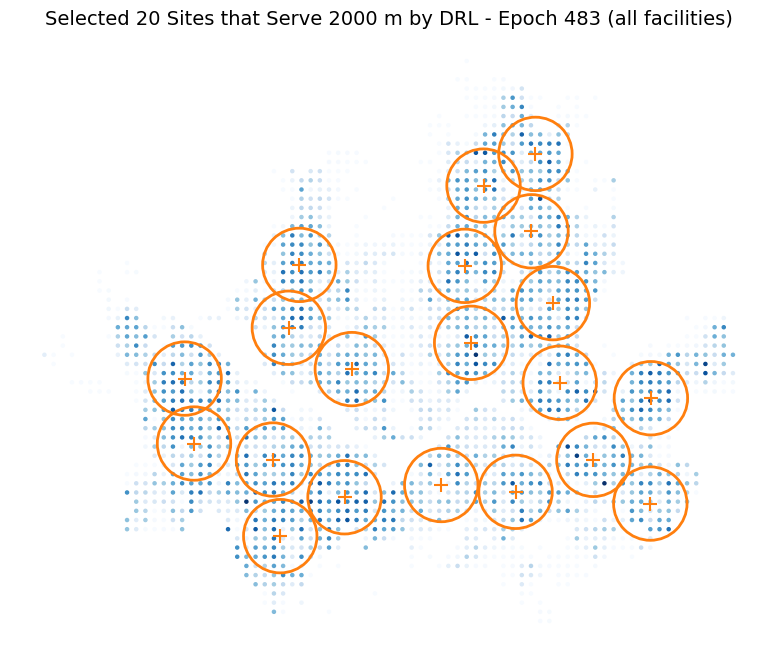

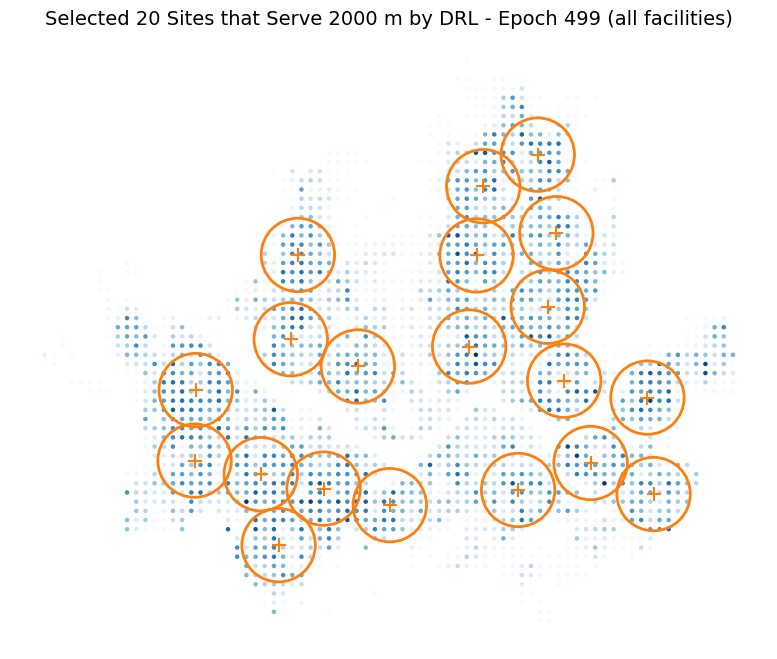

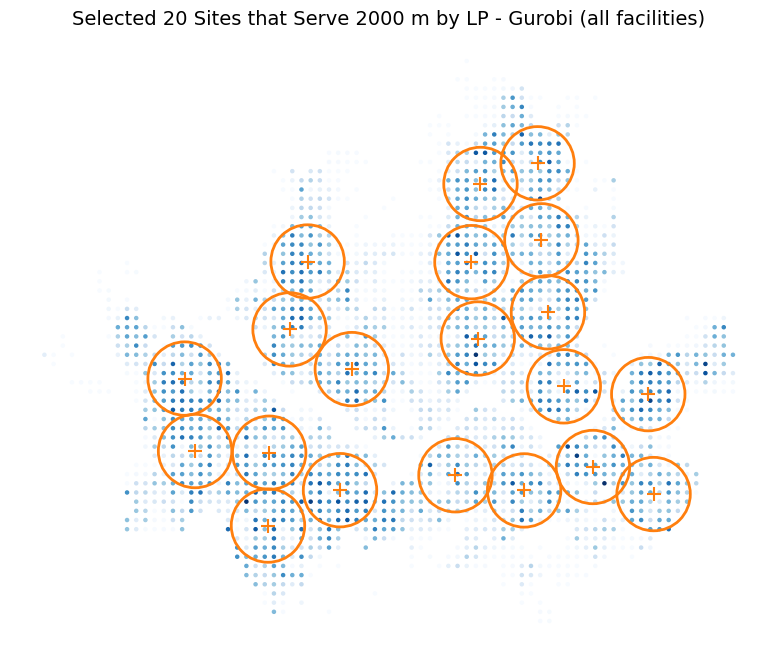

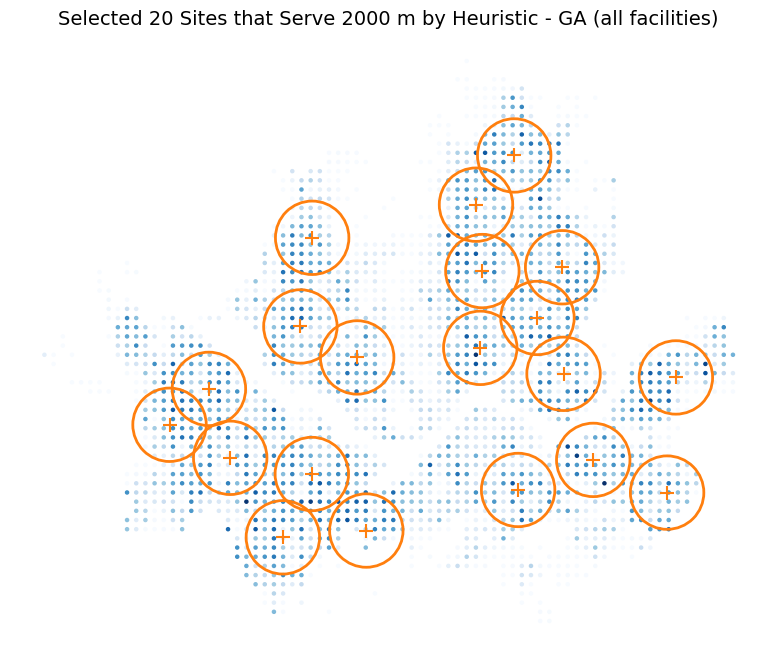

In [126]:
plot_result_simple(seoul_pop_grid, opt_sites1, 2000, 'DRL - Epoch 483 (all facilities)')
plot_result_simple(seoul_pop_grid, opt_sites2, 2000, 'DRL - Epoch 499 (all facilities)')
plot_result_simple(seoul_pop_grid, opt_sites3, 2000, 'LP - Gurobi (all facilities)')
plot_result_simple(seoul_pop_grid, opt_sites4, 2000, 'Heuristic - GA (all facilities)')
plt.show()

# 3. DRL-LP framework configuration & evaluation
## 3-1. k value setup
### p (number of final selected facilities) range: 20 ~ 9000, in increments of 20
- epoch 483 (best) & sampling size 64

- Small p: DRL misses are costly, so use generous k

- Large p: Already saturated, large k yields little benefit, so use moderate k

In [35]:
p_range = sorted(set(
    list(range(20, 301, 20)) +
    list(range(300, 1201, 50)) +
    list(range(1200, 3501, 100))
))

In [27]:
#np.random.seed()
users = np.array(seoul_pop_grid[['NORM_X', 'NORM_Y']])
facilities = np.array(seoul_meds_[['NORM_X', 'NORM_Y']])
demand = np.array(seoul_pop_grid['val_norm'])

In [ ]:
def k_candidates(p, m):
    # alpha candidates
    if p <= 300:
        alphas = [10, 15, 20]
    elif p <= 1200:
        alphas = [5, 8, 10]
    else:  # p <= 3500
        alphas = [2, 3, 5]

    # threshold
    k_min = max(2*p, p + 200)
    ks = [min(m, a*p) for a in alphas]
    ks = [k for k in ks if k >= k_min]
    ks = sorted(set(ks))
    return ks

In [70]:
m = len(seoul_meds_)

In [71]:
for p in [50, 200, 800, 2000, 3500]:
    print(p, "->", k_candidates(p, m))

50 -> [500, 750, 1000]
200 -> [2000, 3000, 4000]
800 -> [4000, 6400, 8000]
2000 -> [4000, 6000, 9076]
3500 -> [7000, 9076]


## 3-2. import DRL model & create function

In [ ]:
def to_batch1(sample_dict, device):
    batch = {}
    for k, v in sample_dict.items():
        if torch.is_tensor(v):
            batch[k] = v.unsqueeze(0).to(device)   # [N,...] -> [1,N,...]
        elif isinstance(v, (int, float)):
            batch[k] = torch.tensor([v], device=device)
        else:
            batch[k] = v
    return batch

In [ ]:
## DRL model: epoch 483

model_class = {
    # 'pointer': PointerNetwork,
    'attention': AttentionModel
}.get(opts.model, None)

assert model_class is not None, "Unknown model: {}".format(model_class)

drl_model = model_class(
    opts.embedding_dim,
    opts.hidden_dim,
    problem,
    n_encode_layers=opts.n_encode_layers,
    mask_inner=True,
    mask_logits=True,
    normalization=opts.normalization,
    tanh_clipping=opts.tanh_clipping,
    checkpoint_encoder=opts.checkpoint_encoder,
    shrink_size=opts.shrink_size,
    dy=False
).to(opts.device)

opts.load_path = './outputs/MCLP/100_20_20260223T212334/epoch-483.pt'

assert opts.load_path is None or opts.resume is None, "Only one of load path and resume can be given"
load_path = opts.load_path if opts.load_path is not None else opts.resume

if load_path is not None:
    print('  [*] Loading the trained model from {}'.format(load_path))
    load_data = torch_load_cpu(load_path)

# Overwrite model parameters by parameters to load
drl_model_ = get_inner_model(drl_model)
drl_model.load_state_dict({**drl_model_.state_dict(), **load_data.get('model', {})})

num_sample = 1
opts.eval_batch_size = 10
opts.max_calc_batch_size = 1280000
width = 64

opts.decode_strategy = 'sampling'
drl_model.eval()
drl_model.set_decode_type(
    "greedy" if opts.decode_strategy in ('bs', 'greedy') else "sampling"
)

  [*] Loading the trained model from ./outputs/MCLP/100_20_20260223T212334/epoch-483.pt


In [ ]:
def drl_get_candidates(sample_dict, drl_model, opts, width, k, m):
    batch = to_batch1(sample_dict, opts.device)

    start = time.time()
    with torch.no_grad():
        sequences, costs = drl_model.sample_many(batch, batch_rep=width, iter_rep=1)
    drl_time = time.time() - start

    if sequences is None:
        raise RuntimeError("DRL returned no sequences.")

    seq_np = sequences.detach().cpu().numpy().reshape(-1)
    cnt = Counter(seq_np.tolist())
    cand_idx = [i for i, _ in cnt.most_common(k)]

    if len(cand_idx) < k:
        all_idx = np.arange(m)
        extra = np.random.choice(np.setdiff1d(all_idx, np.array(cand_idx)), size=k-len(cand_idx), replace=False)
        cand_idx = cand_idx + extra.tolist()

    return cand_idx, drl_time

In [76]:
def lp_on_candidates(users, facilities, demand, p, A, cand_idx):
    fac_sub = facilities[cand_idx, :]
    A_sub = A[cand_idx, :]

    start = time.time()
    x_sub, y_sub, obj = gurobi_solver_MCLP(users, fac_sub, demand, p, A_sub)
    lp_time = time.time() - start

    selected_global = [cand_idx[i] for i in range(len(cand_idx)) if x_sub[i] > 0.9]
    return selected_global, obj, lp_time

In [ ]:
total_runs = sum(len(k_candidates(p, m)) for p in p_range)
print("Total hybrid runs (DRL+LP):", total_runs)

# confirm the number of ks run per p
counts = [(p, len(k_candidates(p, m)), k_candidates(p, m)) for p in p_range]
counts[:10], counts[-10:]

Total hybrid runs (DRL+LP): 160


([(20, 2, [300, 400]),
  (40, 3, [400, 600, 800]),
  (60, 3, [600, 900, 1200]),
  (80, 3, [800, 1200, 1600]),
  (100, 3, [1000, 1500, 2000]),
  (120, 3, [1200, 1800, 2400]),
  (140, 3, [1400, 2100, 2800]),
  (160, 3, [1600, 2400, 3200]),
  (180, 3, [1800, 2700, 3600]),
  (200, 3, [2000, 3000, 4000])],
 [(2600, 3, [5200, 7800, 9076]),
  (2700, 3, [5400, 8100, 9076]),
  (2800, 3, [5600, 8400, 9076]),
  (2900, 3, [5800, 8700, 9076]),
  (3000, 3, [6000, 9000, 9076]),
  (3100, 2, [6200, 9076]),
  (3200, 2, [6400, 9076]),
  (3300, 2, [6600, 9076]),
  (3400, 2, [6800, 9076]),
  (3500, 2, [7000, 9076])])

## 3-3. DRL-LP model run

In [ ]:
out_csv = "hybrid_results_stream.csv"
fieldnames = ["p","k","alpha","objective","time_drl","time_lp","time_total","n_selected","solutions_json"]

write_header = not os.path.exists(out_csv)
f_csv = open(out_csv, "a", newline="", encoding="utf-8-sig")
writer = csv.DictWriter(f_csv, fieldnames=fieldnames)
if write_header:
    writer.writeheader()
    f_csv.flush()

hybrid_results = []
m = len(seoul_meds_)

times_total = []
times_drl = []
times_lp = []

run_count = 0
total_runs = sum(len(k_candidates(p, m)) for p in p_range)

for p in list(reversed(p_range)):
    seoul_meds_, real_datasets = gen_real_data2(seoul_pop_grid, num_sample, p, 2000)
    sample = real_datasets[0]

    for k in k_candidates(p, m):
        t0 = time.time()

        cand_idx, drl_t = drl_get_candidates(sample, drl_model, opts, width, k, m)
        selected_global, obj, lp_t = lp_on_candidates(users, facilities, demand, p, A, cand_idx)

        t_total = time.time() - t0

        times_drl.append(drl_t)
        times_lp.append(lp_t)
        times_total.append(t_total)

        run_count += 1

        if run_count % 10 == 0:
            print(f"[{run_count}/{total_runs}] "
                  f"avg_total={np.mean(times_total):.2f}s, "
                  f"avg_drl={np.mean(times_drl):.2f}s, "
                  f"avg_lp={np.mean(times_lp):.2f}s")

        row = {
            "p": int(p),
            "k": int(k),
            "alpha": float(k / p),
            "objective": float(obj),
            "time_drl": float(drl_t),
            "time_lp": float(lp_t),
            "time_total": float(drl_t + lp_t),
            "n_selected": int(len(selected_global)),
            "solutions_json": json.dumps(selected_global, ensure_ascii=False)
        }

        hybrid_results.append(row)

        writer.writerow(row)
        f_csv.flush()

        print(f"p={p:<4} k={k:<6} | obj={obj:<10.3f} | DRL={drl_t:.2f}s | LP={lp_t:.2f}s | total={drl_t+lp_t:.2f}s | selected={len(selected_global)}")

f_csv.close()

Set parameter MIPFocus to value 2
Set parameter TimeLimit to value 3600
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (win64)

CPU model: 13th Gen Intel(R) Core(TM) i7-13700KF, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 24 logical processors, using up to 24 threads

Optimize a model with 2153 rows, 9152 columns and 320439 nonzeros
Model fingerprint: 0xe6bdb941
Variable types: 0 continuous, 9152 integer (9152 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [4e+03, 4e+03]
Found heuristic solution: objective 8145.9194244
Presolve removed 37 rows and 1545 columns
Presolve time: 0.39s
Presolved: 2116 rows, 7607 columns, 253447 nonzeros
Variable types: 0 continuous, 7607 integer (6766 binary)
Found heuristic solution: objective 8152.9813682
Root relaxation presolve removed 1 rows and 43 columns
Root relaxation presolved: 2115 rows, 7564 columns, 253239 nonzeros




## 3-4. DRL only model run

In [ ]:
def drl_solve_single(sample_dict, drl_model, opts, width):

    batch = to_batch1(sample_dict, opts.device)

    start = time.time()
    with torch.no_grad():
        sequences, costs = drl_model.sample_many(batch, batch_rep=width, iter_rep=1)
    drl_time = time.time() - start

    if sequences is None:
        raise RuntimeError("DRL returned no sequences.")

    costs_np = costs.detach().cpu().numpy().reshape(-1)
    seq_np = sequences.detach().cpu().numpy()

    seq_np = seq_np.reshape(len(costs_np), -1)  # (n_solutions, p)

    best_idx = int(np.argmin(costs_np))
    selected = seq_np[best_idx].tolist()

    objective = -float(costs_np[best_idx])

    return selected, objective, drl_time

In [ ]:
drl_only_results = []

m = len(seoul_meds_)

for p in list(reversed(p_range)):
    try:
        seoul_meds_, real_datasets = gen_real_data2(seoul_pop_grid, num_sample, p, 2000)
        sample = real_datasets[0]

        selected_idx, obj, runtime = drl_solve_single(sample, drl_model, opts, width)

        drl_only_results.append({
            "method": "DRL",
            "m": m,
            "p": p,
            "objective": obj,
            "time": runtime,
            "n_selected": len(selected_idx),
            "solutions": selected_idx
        })

        print(f"[DRL] p={p:<4} | obj={obj:<10.3f} | time={runtime:.2f}s | selected={len(selected_idx)}")

    except Exception as e:
        print(f"[DRL] Error at p={p}: {str(e)}")

entire_results_drl_only = pd.DataFrame(drl_only_results)

[DRL] p=3500 | obj=8094.471   | time=32.35s | selected=3500
[DRL] p=3400 | obj=8081.751   | time=24.45s | selected=3400
[DRL] p=3300 | obj=8077.972   | time=26.33s | selected=3300
[DRL] p=3200 | obj=8064.519   | time=25.60s | selected=3200
[DRL] p=3100 | obj=8023.020   | time=24.48s | selected=3100
[DRL] p=3000 | obj=8014.528   | time=23.52s | selected=3000
[DRL] p=2900 | obj=7993.880   | time=22.77s | selected=2900
[DRL] p=2800 | obj=8003.173   | time=21.76s | selected=2800
[DRL] p=2700 | obj=7961.678   | time=21.01s | selected=2700
[DRL] p=2600 | obj=7928.248   | time=20.44s | selected=2600
[DRL] p=2500 | obj=7911.616   | time=19.79s | selected=2500
[DRL] p=2400 | obj=7824.470   | time=18.96s | selected=2400
[DRL] p=2300 | obj=7772.045   | time=18.26s | selected=2300
[DRL] p=2200 | obj=7771.125   | time=17.65s | selected=2200
[DRL] p=2100 | obj=7671.864   | time=17.42s | selected=2100
[DRL] p=2000 | obj=7581.675   | time=16.19s | selected=2000
[DRL] p=1900 | obj=7490.794   | time=15.

## 3-5. LP only model run

In [ ]:
lp_only_results = []

real_radius = 2000
radius = real_radius/S
A = np.sqrt(np.sum((facilities[:, np.newaxis, :] - users[np.newaxis, :, :]) ** 2, axis=-1))
A = (A <= radius).astype(int)

for p in list(reversed(p_range)):
    try:
        start = time.time()
        x_result, y_result, obj = gurobi_solver_MCLP(users, facilities, demand, p, A)
        runtime = time.time() - start

        solutions = [i for i in range(m) if x_result[i] > 0.9]

        lp_only_results.append({
            "method": "LP",
            "m": m,
            "p": p,
            "objective": float(obj),
            "time": runtime,
            "n_selected": len(solutions),
            "solutions": solutions
        })

        print(f"[LP ] p={p:<4} | obj={obj:<10.3f} | time={runtime:.2f}s | selected={len(solutions)}")

    except Exception as e:
        print(f"[LP ] Error at p={p}: {str(e)}")

entire_results_lp_only = pd.DataFrame(lp_only_results)

Set parameter Username
Set parameter LicenseID to value 2646023
Academic license - for non-commercial use only - expires 2026-04-01


Set parameter MIPFocus to value 2
Set parameter TimeLimit to value 3600
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (win64)

CPU model: 13th Gen Intel(R) Core(TM) i7-13700KF, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 24 logical processors, using up to 24 threads

Optimize a model with 2153 rows, 11228 columns and 407939 nonzeros
Model fingerprint: 0xeccdf64a
Variable types: 0 continuous, 11228 integer (11228 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [4e+03, 4e+03]
Found heuristic solution: objective 8159.0239155
Presolve removed 102 rows and 3959 columns
Presolve time: 0.60s
Presolved: 2051 rows, 7269 columns, 297624 nonzeros
Variable types: 0 continuous, 7269 integer (6055 binary)
Found heuristic solution: objective 8160.0239155
Root relaxation presolve removed 374 rows and 775 columns
Root relaxation presolved: 1677 rows, 6494 columns, 259022 nonz

## 3-6. model results comparison

In [ ]:
entire_results_hybrid = pd.DataFrame(hybrid_results)
entire_results_hybrid = entire_results_hybrid.rename({'solutions_json':'solutions'}, axis = 1)

In [ ]:
entire_results_drl_only = entire_results_drl_only.rename({'time':'time_total'}, axis = 1)
entire_results_lp_only = entire_results_lp_only.rename({'time':'time_total'}, axis = 1)

In [98]:
entire_results_hybrid["method"] = "Hybrid"
entire_results_hybrid['m'] = 9076

compare_df = pd.concat(
    [
        entire_results_hybrid[["method","m","p","k","alpha","objective","time_drl","time_lp","time_total", 'n_selected', 'solutions']],
        entire_results_drl_only[["method","m","p","objective","time_total","n_selected","solutions"]],
        entire_results_lp_only[["method","m","p","objective","time_total","n_selected","solutions"]],
    ],
    ignore_index=True,
    sort=False
)

In [35]:
df = compare_df.copy()

df["p_group"] = pd.cut(
    df["p"],
    bins=[-np.inf, 300, 1200, np.inf],
    labels=["p ≤ 300", "300 < p ≤ 1200", "p > 1200"]
)

In [45]:
df_copy2 = df[df.k!=9076].reset_index(drop = True)

In [ ]:
summary = (
    df_copy2.groupby(["method", "p_group"], observed=True)
      .agg(
          obj_min=("objective", "min"),
          obj_max=("objective", "max"),
          obj_avg=("objective", "mean"),
          time_min=("time_total", "min"),
          time_max=("time_total", "max"),
          time_avg=("time_total", "mean")
      )
)

summary = summary.round(3)

In [53]:
summary

obj_min   obj_max   obj_avg  time_min  time_max  \
method p_group                                                            
DRL    p ≤ 300         4883.845  6831.213  6473.229     2.278     4.240   
       300 < p ≤ 1200  6923.356  7263.190  7102.428     4.579    10.538   
       p > 1200        7290.696  8094.471  7752.455    11.115    32.348   
Hybrid p ≤ 300         4905.882  8160.029  7942.885    12.471   191.873   
       300 < p ≤ 1200  8144.589  8161.029  8157.960    59.549   288.086   
       p > 1200        8147.604  8161.029  8157.508    92.069   731.455   
LP     p ≤ 300         5084.236  8161.029  7916.222   690.149  4367.347   
       300 < p ≤ 1200  8161.029  8161.029  8161.029   686.966   692.703   
       p > 1200        8161.029  8161.029  8161.029   478.415   796.880   

                       time_avg  
method p_group                   
DRL    p ≤ 300            3.268  
       300 < p ≤ 1200     7.582  
       p > 1200          19.287  
Hybrid p ≤ 300           84.713  
       300 < p ≤ 1200   167.974  
       p > 1200         257.122  
LP     p ≤ 300         1224.115  
       300 < p ≤ 1200   689.971  
       p > 1200         703.928